<img src="images\Logo_UCLL_ENG_RGB.png" style="background-color:white;" />

# Data Analytics & Machine learning

Lecturers: Aimée Lynn Backiel, Lies Bollens, Fien Van de Woestijne

Academic year 2026-2027

## Lab 2: Data analytics with Pandas

### Recap of last lab(s)

#### Lab 1

1. We ensured we had a valid Python installation.
2. We learnt what a virtual environment is:
   * Isolated Python executable and packages.
   * We created a virtual environment.
3. Absolute path vs relative path recap.
4. Recap of data structures in Python

#### Lab 2
1. Installed Pandas
2. Learnt how to read data
3. Learnt how to calculate mean, mode, median etc.
4. Basic exploration of the 4 variables
5. Bivariate exploration

### The case

Ada Turing Travelogue, or as everyone calls her, Ada just started working part time at her parents travel agency. She has a keen understanding and interest of everything related to applied computer science ranging from server & system management to full stack software development. Through database foundations she already understands how to query data and programming 1 and 2 covered the essentials about the Python programming language. Recently she has just decided to start learning about data analytics & machine learning as well.

She uses her skills to connect to the travel agency's database where she finds many, normalized, tables. Ada recalls what she learnt in database foundations and performs all the correct joins. Afterwards she saves the data in the `data/` folder.


She finds the following dataset:

| Column Name          | Description                                                                                       |
| -------------------- | ------------------------------------------------------------------------------------------------- |
| SalesID              | Unique identifier for each sale.                                                                  |
| Age                  | Age of the traveler.                                                                              |
| Country              | Country of origin of the traveler.                                                                |
| Membership_Status    | Membership level of the traveler in the booking system; could be 'standard', 'silver', or 'gold'. |
| Previous_Purchases   | Number of previous bookings made by the traveler.                                                 |
| Destination          | Travel destination chosen by the traveler.                                                        |
| Stay_length          | Duration of stay at the destination.                                                              |
| Guests               | Number of guests traveling (including the primary traveler).                                             |
| Travel_month         | Month in which the travel is scheduled.                                                           |
| Months_before_travel | Number of months prior to travel that the booking was made.                                       |
| Earlybird_discount   | Boolean flag indicating whether the traveler received an early bird discount.                     |
| Package_Type         | Type of travel package chosen by the traveler.                                                    |
| Cost                 | Calculated cost of the travel package.                                                            |
| Margin | The cost (for the traveler) - what the travel agency pays. |
 | Additional_Services_Cost| The amount of additional services (towels, car rentals, room service, ...) that was bought during the trip. |


### Helping Ada explore the dataset

The main goal for the remainder of this lab is to explore the data. We will specifically take five columns:

* cost
* age
* stay_length
* destination
* country

Our goal is to find interesting relationships between them.

As was covered in the book and lecture there are two main data types in analytics: categorical and numerical data. This is a crucial first step in your analysis because it determines what methods make sense on your data.


**The goal is primarily to find out what influences the cost of the stay.**

### Part 1: Recap from last week

#### Reading and exploring data: univariate

In [704]:
import pandas as pd # by convention
pd.options.display.float_format = '{:.2f}'.format

In [705]:
travel_dataset = pd.read_csv("data/lab_3_dataset.csv")

Let's have a very short refresher of last week's lab. One of the first things you typically do with a dataset is print out the first few rows. 

In [706]:
travel_dataset.head()

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09


Accessing the columns is equally trivial.

In [707]:
travel_dataset.columns

Index(['Unnamed: 0', 'sales_id', 'age', 'country', 'membership_status',
       'previous_purchases', 'destination', 'stay_length', 'guests',
       'travel_month', 'months_before_travel', 'earlybird_discount',
       'package_Type', 'cost', 'rating', 'margin', 'additional_services_cost'],
      dtype='str')

We can also make subsets like this:

In [708]:
columns = ["country", "stay_length", "age", "cost", "destination"]
travel_dataset_subset = travel_dataset[columns]
travel_dataset_subset

,country,stay_length,age,cost,destination
0,UK,4,47,1706.09,Sydney
1,Italy,4,37,281233.19,Tokyo
2,USA,3,49,2829.92,Sydney
3,Spain,7,62,2789.53,Cape Town
4,Germany,9,36,5358.00,Paris
...,...,...,...,...,...
9995,Germany,11,59,7504.78,Cape Town
9996,Australia,6,18,1427.12,Sydney
9997,USA,5,29,3458.86,Paris
9998,USA,16,47,18392.27,Paris


##### ❓ Summarize all the numerical variables with one line of code. Write down everything you notice about the variable cost.

In [709]:
travel_dataset_subset.describe()

,stay_length,age,cost
count,10000.00,10000.00,10000.00
mean,10.49,39.98,114814.74
std,7.05,14.00,457712.61
min,1.00,18.00,-1000000.00
25%,5.00,29.00,2414.47
50%,9.00,39.00,4845.14
75%,14.00,50.00,10222.98
max,68.00,80.00,6724039.17


My observation:
- Minimum value: The minimum cost is -1,000,000.00, representing system errors rather than real travel costs.
- Maximum value: The maximum cost is 6,724,039.17, which is drastically higher than the 75th percentile (10,222.98).
- Distorted mean: Because of these extreme negative values and unscaled amounts, the mean (114,814.74) does not reflect typical trip costs.
- Median: The 50th percentile (median) is 4,845.14, showing that most normal trips cost in the low thousands.

##### ❓ Summarize one of the categorical variables.

In [710]:
travel_dataset["destination"].value_counts()

destination
Rio          1293
Sydney       1275
Cairo        1271
Paris        1259
Tokyo        1252
New York     1229
Cape Town    1224
Rome         1197
Name: count, dtype: int64

My observation:
The dataset contains 8 distinct travel destinations.

### Part 2: Data exploration - bivariate


Now we will look at pairs of variables, to see if we find any interesting relations between two variables. This analysis takes multiple steps.
1) First, you decide which two variables might be interesting to look at together
2) Second, you have to decide upon a technique for analysis. This technique will differ depending on the type of variable. The different combinations are: two numerical variables, two categorical variables and one categorical and one numerical variable. 
3) Depending on the type of variables, you can carry out different analysis. We will explore this below, with one example for each type, to give you an idea of what different analysis looks like for different types of variables. 

Later, when you encounter two other variables you want to analyse, you can use these examples as a blueprint to start carrying out the correct analysis. 

##### ❓ Which variables do you think are interesting to take a look at together?  Write a short motivation on why you would like to look at them and why you chose this technique to analyse this. Then carry out the proper analysis. Choose at least three different combinations: two categorical, two numerical, and one categorical and a numerical variable. Don't lose sight of what we are trying to figure out: what influences the cost of the stay. End your answer with what you observe from your analysis.



##### 1) Two numerical variables:
- Why do you look at them? 
- What technique do you use and why? 


My motivation:
To test the assumption that longer stays lead to higher package costs.

In [711]:
travel_dataset[["stay_length", "cost"]].corr()

,stay_length,cost
stay_length,1.00,0.22
cost,0.22,1.00


My observation:
The raw correlation is weak (~0.22) because corrupted and unscaled cost values distort the linear relationship.

##### 2) One numerical variable and one categorical variable: 

- Why do you look at them? 
- What technique do you use and why? 

My motivation: To evaluate whether certain destinations command premium prices.

In [712]:
travel_dataset.groupby("destination")["cost"].mean()

destination
Cairo        -3599.38
Cape Town    -7622.93
New York     -2176.54
Paris        -3527.71
Rio          -4781.88
Rome         -3456.09
Sydney       -4994.68
Tokyo       947170.23
Name: cost, dtype: float64

My observation:
- Tokyo has an average cost of 947,170.23, which is inflated by around 150x due to unscaled Japanese Yen.
- All other destinations display negative average costs (between -2,176 and -7,622) due to the presence of -1,000,000.00 error rows. 

##### 3 ) Two categorical variables:

This analysis will follow the same structure as before. Now, it's up to you to create your own markdown and code cells. 

My motivateion: To examine whether travelers from certain origin countries prefer specific holiday destinations.

In [713]:
pd.crosstab(travel_dataset["country"], travel_dataset["destination"])

destination,Cairo,Cape Town,New York,Paris,Rio,Rome,Sydney,Tokyo
country,,,,,,,,
Australia,151,158,169,135,158,162,149,140
Canada,154,149,142,153,184,138,141,153
France,159,152,134,171,159,155,159,177
Germany,152,139,147,161,152,126,150,145
Italy,182,165,157,149,146,158,176,141
Spain,144,165,152,163,155,159,168,159
UK,173,156,166,166,173,150,172,164
USA,156,140,162,161,166,149,160,173


My observation:
Traveler counts are distributed roughly evenly across all origin-destination combinations (around 130–180 travelers per pair), showing no strong preference of specific nationalities for particular destinations.

##### ❓ Extra: I'd like to study age and cost using the groupby method. Is that a good idea? Explain why or why not. If not, do you see a way to make it work?




My explanation:
Directly grouping by individual ages (travel_dataset.groupby("age")["cost"].mean()) is not a good idea because age has over 60 distinct discrete numerical values, resulting in many small, fragmented, and noisy groups. A better approach to make it work is binning the ages into broader categories using pd.cut() before grouping.

In [714]:
travel_dataset.groupby(pd.cut(travel_dataset["age"], bins=[18, 30, 45, 60, 85]))["cost"].mean()

age
(18, 30]    95794.03
(30, 45]   110236.14
(45, 60]   129107.40
(60, 85]   131093.80
Name: cost, dtype: float64

##### ❓ If you have not done so before, analyze cost per destination. Do you notice any abnormal results?


In [715]:
travel_dataset.groupby("destination")["cost"].mean()

destination
Cairo        -3599.38
Cape Town    -7622.93
New York     -2176.54
Paris        -3527.71
Rio          -4781.88
Rome         -3456.09
Sydney       -4994.68
Tokyo       947170.23
Name: cost, dtype: float64

My observation:
- Tokyo has an average cost of 947,170.23, which is roughly 150 times higher than realistic travel costs.
- Every other destination displays a negative average cost (e.g., Cape Town at -7,622.93, Cairo at -3,599.38), caused by corrupted -1,000,000.00 error rows.

##### ❓ How would you deal with this?

My answer:
- Filter out all invalid rows where cost <= 0 (or cost == -1000000.00).
- Divide Tokyo's cost by 158 to convert Japanese Yen back into the standard currency.   

### Part 3:  Subsetting and cleaning data

Ada gets confirmation from her contacts that the data has some issues. The booking system broke down and produced large negative values. Additionally, the currency converter for Tokyo is giving incorrect results.

We will help her rectify these mistakes.

#####  Removing data: boolean indexing

Generally it's a good idea to not alter your original dataset but filter it in a copy. The way Pandas does this is by filtering with a boolean mask. We will demonstrate step by step how to do this.

<center>
<img src="https://numpy.org/doc/stable/_images/broadcasting_1.png" style="background-color:white;">
</center>

The data we want gone are the rows where the cost equals `-1000000.00`. We can check for each row if that's the case. 

Pandas uses a technique called "broadcasting" where if you try to do operations between values of different shapes Pandas will try to expand one to make them match.

This means you don't need to explicitly turn the value into an array of the same size.

In [716]:
non_errors = travel_dataset["cost"] != -1000000.00
non_errors

0       True
1       True
2       True
3       True
4       True
        ... 
9995    True
9996    True
9997    True
9998    True
9999    True
Name: cost, Length: 10000, dtype: bool

❓ Check how many non_errors we have in the dataset

In [717]:
(travel_dataset["cost"] != -1000000.00).sum()

np.int64(9900)

❓ Is explicitly checking if the cost does not equal -1000000.00 the best way to filter out wrong cost values? Adapt the checking for non_errors to a more logical constraint. See if we still have the same number of errors.

In [718]:
non_errors = travel_dataset["cost"] > 0
non_errors.sum()

np.int64(9900)

Pandas allows you to give a boolean array as an index to filter out rows. The rows where the boolean array (also known as a mask) is `True` are kept. 

In [719]:
travel_dataset[non_errors] 

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25


We can also combine all of the above in one line, to directly filter out all the values with a faulty cost 

In [720]:
travel_dataset[travel_dataset["cost"] > 0]
# or this: travel_dataset[travel_dataset["cost"] != -1000000.00]

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25


##### ❓Create a new dataset called `_dataset_cleaned` , which contains only the rows with a non faulty value. Make a copy of the original dataset, such that we do not accidentally alter values in the original dataset 

In [721]:
_dataset_cleaned = travel_dataset[travel_dataset["cost"] > 0].copy()

##### ❓ Make a mask for the people that traveled to Tokyo. Call the variable `tokyo`.

In [722]:
tokyo = _dataset_cleaned["destination"] == "Tokyo"

#####  Updating rows the right way

We can now grab the rows where the destination is Tokyo as follows

In [723]:
_dataset_cleaned[tokyo]

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
6,6,7,63,Italy,silver,4,Tokyo,1,1,6,1,False,Cultural,37424.42,7,-89.33,81.53
7,7,8,51,Spain,silver,3,Tokyo,11,2,7,3,True,Adventure,810452.74,5,4882.30,1509.58
11,11,12,33,Australia,standard,3,Tokyo,4,3,7,5,True,Adventure,445455.58,7,2574.81,738.01
27,27,28,45,Spain,silver,4,Tokyo,19,3,2,11,True,Relaxation,1796515.55,6,11144.05,3772.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9936,9936,9937,44,Australia,gold,5,Tokyo,2,2,8,14,True,Cultural,143747.78,8,798.81,123.23
9958,9958,9959,49,Australia,standard,1,Tokyo,9,1,8,3,False,Adventure,320119.76,6,1727.44,702.34
9965,9965,9966,47,Spain,standard,2,Tokyo,5,2,2,1,False,Adventure,324200.00,5,1661.63,494.94
9986,9986,9987,34,Italy,standard,3,Tokyo,5,3,12,8,False,Relaxation,535010.48,6,3011.18,875.61


This gives us a filtered dataset of all people that traveled to Tokyo, with the faulty values already removed.
We can take a look at the cost column as follows

In [724]:
_dataset_cleaned[tokyo]["cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

Now we have the rows we can convert the currency by dividing by 158, to get the correct price. 
You will likely try to do this in the following way:

`_dataset_cleaned[tokyo]["cost"] /= 158`

You can try it out below and look at the result

In [725]:
_dataset_cleaned[tokyo]["cost"] /= 158

/tmp/ipykernel_28703/740947496.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  _dataset_cleaned[tokyo]["cost"] /= 158


This gives us the same error as we encountered in the previous session. The way we can get around is is by using `data.loc`.

When we read the error message, it tells us two things: 
1) The abovementioned code currently still works in certain cases, but in the future it will not work anymore. 

*This is a sure sign that we should not use this line of code anymore. If we would, in the future, it might suddenly break and not function anymore. Right now, we know where we are coding and can easily update this line of code. But, in the future, we might have a whole project with 1000s of lines of code. If you then have to look for where exactly the error occurs, you will end up spending a long time doing something not very fun. Think about future you.*

2) to use  `df.loc[row_indexer, "col"] = values` instead, since this will ensure we **keep on updating the original dataframe**. 



`df.loc` can be quite confusing. It is an object you can slice by using square brackets `[]`. The first element is the **index**. This is typically the column on the far left.

In [726]:
_dataset_cleaned.index # Each dataframe has an index, which is shown on the left. It typically starts at 0 and goes to the number of rows - 1.

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9990, 9991, 9992, 9993, 9994, 9995, 9996, 9997, 9998, 9999],
      dtype='int64', length=9900)

In [727]:
tokyo.index # Each series has an index too

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9990, 9991, 9992, 9993, 9994, 9995, 9996, 9997, 9998, 9999],
      dtype='int64', length=9900)

In [728]:
_dataset_cleaned.loc[tokyo] # Loc filters the dataset where tokyo is true  

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
6,6,7,63,Italy,silver,4,Tokyo,1,1,6,1,False,Cultural,37424.42,7,-89.33,81.53
7,7,8,51,Spain,silver,3,Tokyo,11,2,7,3,True,Adventure,810452.74,5,4882.30,1509.58
11,11,12,33,Australia,standard,3,Tokyo,4,3,7,5,True,Adventure,445455.58,7,2574.81,738.01
27,27,28,45,Spain,silver,4,Tokyo,19,3,2,11,True,Relaxation,1796515.55,6,11144.05,3772.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9936,9936,9937,44,Australia,gold,5,Tokyo,2,2,8,14,True,Cultural,143747.78,8,798.81,123.23
9958,9958,9959,49,Australia,standard,1,Tokyo,9,1,8,3,False,Adventure,320119.76,6,1727.44,702.34
9965,9965,9966,47,Spain,standard,2,Tokyo,5,2,2,1,False,Adventure,324200.00,5,1661.63,494.94
9986,9986,9987,34,Italy,standard,3,Tokyo,5,3,12,8,False,Relaxation,535010.48,6,3011.18,875.61


In [729]:
_dataset_cleaned.loc[tokyo, "cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

It is a good habit to make a copy before you change your data. If you don't do this and make a mistake you need to rerun your entire script. For a small dataset like this it's not a big problem, but as you scale it can become a bottleneck.

In [730]:
cleaned_dataset = _dataset_cleaned.copy()

In [731]:

cleaned_dataset.loc[tokyo, "cost"] /= 158

In [732]:
_dataset_cleaned

,Unnamed: 0,sales_id,age,country,membership_status,previous_purchases,destination,stay_length,guests,travel_month,months_before_travel,earlybird_discount,package_Type,cost,rating,margin,additional_services_cost
0,0,1,47,UK,silver,1,Sydney,4,2,7,1,False,Adventure,1706.09,6,1219.74,291.06
1,1,2,37,Italy,silver,5,Tokyo,4,2,8,4,False,Adventure,281233.19,7,1570.39,405.52
2,2,3,49,USA,standard,2,Sydney,3,4,7,1,False,Cultural,2829.92,6,2360.49,285.36
3,3,4,62,Spain,silver,2,Cape Town,7,2,1,3,True,Adventure,2789.53,7,2315.66,747.53
4,4,5,36,Germany,silver,3,Paris,9,3,2,7,False,Adventure,5358.00,5,5042.14,1117.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,9996,59,Germany,standard,3,Cape Town,11,3,8,1,True,Adventure,7504.78,7,7045.05,1602.18
9996,9996,9997,18,Australia,standard,1,Sydney,6,1,7,1,True,Relaxation,1427.12,7,1051.24,395.36
9997,9997,9998,29,USA,silver,3,Paris,5,3,12,2,True,Adventure,3458.86,5,2945.36,539.41
9998,9998,9999,47,USA,standard,5,Paris,16,5,8,3,False,Relaxation,18392.27,5,17968.59,5247.25


We can also give columns or a list of columns to `.loc`. In this case only the rows we ask for will be returned

In [733]:
_dataset_cleaned.loc[tokyo, "cost"]

1       281233.19
6        37424.42
7       810452.74
11      445455.58
27     1796515.55
          ...    
9936    143747.78
9958    320119.76
9965    324200.00
9986    535010.48
9991     67273.96
Name: cost, Length: 1239, dtype: float64

It is a good habit to make a copy before you change your data. If you don't do this and make a mistake you need to rerun your entire script. For a small dataset like this it's not a big problem, but as you scale it can become a bottleneck.


##### ❓ create a new copy of the dataset, called `cleaned_dataset`. Use the df.loc function to divide the cost of the trips to Tokyo by 158. 



In [734]:
cleaned_dataset = _dataset_cleaned.copy()
cleaned_dataset.loc[tokyo, "cost"] /= 158

##### ❓We will briefly look at the impact of what we did on our analysis of cost by destination. What effect did our corrections have on the data?

In [735]:
cleaned_dataset.groupby("destination")["cost"].mean()

destination
Cairo       5897.69
Cape Town   5521.14
New York    6009.05
Paris       6061.44
Rio         5325.80
Rome        5786.73
Sydney      5254.98
Tokyo       6124.05
Name: cost, dtype: float64

My observation:
- Negative average costs across all non-Tokyo destinations have disappeared now that the -1,000,000.00 error values were eliminated.
- Tokyo's average cost dropped from roughly 947,170.23 down to 6,124.05, bringing it completely in line with the other destinations (which all average between 5,254.98 and 6,061.44).

##### ❓Compare the correlation between age, cost and stay length before and after data cleaning. What differences do you see?

In [736]:
travel_dataset[["age", "cost", "stay_length"]].corr()

,age,cost,stay_length
age,1.00,0.03,0.00
cost,0.03,1.00,0.22
stay_length,0.00,0.22,1.00


In [737]:
cleaned_dataset[["age", "cost", "stay_length"]].corr()

,age,cost,stay_length
age,1.00,0.02,0.00
cost,0.02,1.00,0.75
stay_length,0.00,0.75,1.00


My observation:
- The correlation between stay_length and cost jumped significantly from 0.22 before cleaning to 0.75 after cleaning.
- The correlation between age and cost remained essentially unchanged near zero (0.03 before vs. 0.02 after).
- The correlation between age and stay_length remained close to zero (0.001).


##### ❓ How do we interpret these correlations? Why do you think the correlations changed so much? 

My explanation:
- Interpretation: An $r \approx 0.75$ means there is a strong positive linear relationship between the duration of stay and the total trip cost (longer trips systematically cost more). Age shows virtually no linear relationship with cost ($r \approx 0.02$).
- Why it changed so drastically: Pearson's correlation coefficient depends on covariance and standard deviation, which are extremely sensitive to outliers. The uncleaned dataset had massive negative values (-1,000,000) and unscaled Japanese Yen values for Tokyo (158x larger), which introduced enormous artificial variance and suppressed the underlying linear relationship between stay duration and cost.

Extra food for thought: 
- correlation only gives a measure of linear relationships. Low correlations don't always mean an absence of a relationship, it could be there but just non-linear.
- a correlation measures the fact that there is **a** linear relationship. However, how exactly to interpret these numbers is not necessarily straightforward. 


How do we interpret our correlation value of 0.75?

**What correlation does NOT mean**
> If variable A increases with 1 unit variable B increases with 0.75 units.

**Why is this not the interpretation?** 

The (sample) correlation $r_{X,Y}$ is given as:

$$
r_{x,y} = \frac{cov(x,y)}{(n-1)s_{x}s_{y}} = \frac{\sum_{i=1}^{n}{(x_{i} - \bar{x})(y_{i} - \bar{y})}}{(n-1)s_{x}s_{y}}
$$

We have some notation to unpack here.

We have two variables $x$ and $y$. These each have a mean $\bar{x}$ and $\bar{y}$ pronounced as x bar and y bar respectively, $s_{x}$ and $s_{y}$ are respectively the standard deviations of x and y.

The first equality shows us that the correlation $r_{x, y}$ is a normalized version of something called the covariance (cov). The scaling is achieved by dividing by a factor related to the product of the standard deviations of the two variables. This is what ensures that $r_{x,y} \in [-1, 1]$. 

Thee covariance expresses the joint variability of two variables. A covariance of 8 means that if variable x increased by 1 the other variable increases by an amount that is dependent on the units and scale of both variables; it doesn't specify a fixed number of units either.

Thus, the correct interpretation of a correlation coefficient is: 

> A correlation coefficient, measures the strength and direction of a linear relationship between two variables, but not the slope of that relationship.

Finally, to know how much one variable varies in function of the other we can look at the regression slope:

$$
\beta_{y} = r_{x,y}\frac{s_{x}}{s_{y}}
$$

The slope of the regression has a deep connection with the correlation. It's the correlation weighted by the proportion of the standard deviations. Logically, if $s_{x} = s_{y}$ the interpretation given last lecture holds. Generally that is not the case, so those that made this remark last lecture were correct. The equation above shows that it is trivial to recover the slope from the correlation.

It is important to remember that correlations and the slope of a regression are expressing linear relationships. As discussed last lecture Anscombe's quartet consists of four datasets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed. **This highlights the importance of visualizing data and not relying solely on statistical metrics.**



<center>
Anscomnbe's quarter: four datasets with an equal correlation.
<br>
<br>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" style="width:50%">
</center>

### Introduction to plotting with Matplotlib, Seaborn and Plotly

We have helped Ada so far to gain insights into her data by wrangling it into shape and making tables to summarize data. Now, to further enhance our understanding and visualize the patterns, trends, and potential anomalies, we will be plotting the data. 

Making data visual simplifies complex datasets and also makes it more intuitive for stakeholders to grasp key takeaways. By transitioning from tabular summaries to graphical plots, we can also communicate more effectively.

#### Matplotlib

<center>
<img src="https://matplotlib.org/stable/_images/sphx_glr_logos2_003.png" style="background-color:white">
</center>

The name matplotlib comes from matrix plotting library. It's a descendant from the MATLAB programming language. It's by now an older library (2003) that has some quirks, but it is still important to know the basics of Matplotlib since other Python plotting libraries build on top of it. 

In [738]:
# uncomment to install
#%pip install matplotlib 

In [739]:
import matplotlib.pyplot as plt # convention

##### Plotting univariate data


The table below is a summary of the different types of plots for **numeric data**.

| Plot Type          | Description                                           | When to Use                                                      |
|--------------------|-------------------------------------------------------|------------------------------------------------------------------|
| **Histogram**      | Displays the distribution of a single continuous variable by dividing the data into bins and showing the frequency of observations in each bin. | To visualize the distribution of a variable, especially to identify its central tendency (mean), spread (standard deviation), and skewness (are low or high values more common).  |
| **Box Plot (or Whisker Plot)** | Shows the distribution of a variable using quartiles and displays potential outliers. | To get a summary of a variable's distribution in terms of its median, quartiles, and possible outliers. Useful when comparing the distribution across categories. |
| **Density Plot (or Kernel Density Plot)** | Provides a smoothed version of a histogram. | To visualize the distribution of a variable in a continuous manner. Particularly useful when comparing the distributions of multiple variables on the same plot. |
| **Violin Plot**    | Combines aspects of box plots and density plots.       | To visualize both the distribution and summary statistics of a variable. Especially useful when comparing across different categories. |


The syntax for plotting is generally `plt.<plotType>(x, y)`. 

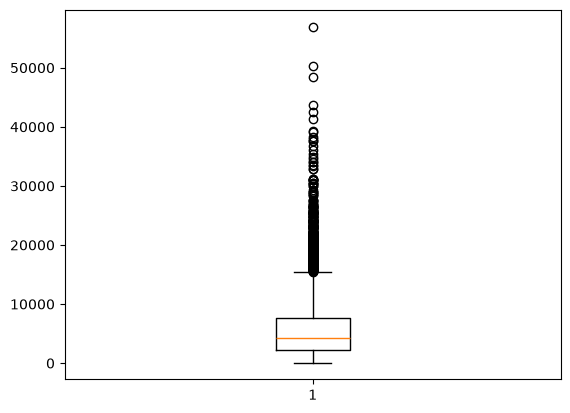

In [740]:
plt.boxplot(cleaned_dataset["cost"]); # Matplotlib prints things while plotting, the semicolon an suppress it.

A boxplot provides a comprehensive view of a dataset's distribution, offering more detailed insights than typical tables. The central line within the box represents the median, splitting the data into its lower and upper halves. The box itself is framed by two lines: the lower boundary represents the 25th percentile (or Q1), meaning 25% of the data lies below this value, and the upper boundary denotes the 75th percentile (or Q3), indicating that 75% of the data is below this point.

The range between Q3 and Q1 is known as the Interquartile Range (IQR). Beyond the box, the plot extends 'whiskers'. Their "distance" is calculated as `1.5 * IQR` both above and below the box, providing a range for typical data points. Any data outside these whiskers can be considered possible outliers.

##### ❓ What can we learn from this boxplot? Try answering the following questions in your response:
* is the data symmetrical, or skewed? How did you see this? What does that mean for the cost variable?
* is there a large spread in the data or not? How did you see this? What does that mean for the cost variable?
* where does most of the data lie? Are there any points that differ significantly from the others?  

My observation:
- my answer: The distribution is right-skewed (positively skewed). The median line lies close to the 25th percentile ($Q_1 \approx 2,293$, median $\approx 4,226$), and the upper whisker extends far upward with many points beyond it.
- my answer: Moderate to high spread. The Interquartile Range (IQR) spans from 2,293 to 7,560, with values reaching up to ~56,969.
- my answer: 50% of trips cost between 2,293 and 7,560. Numerous values exceed $Q_3 + 1.5 \times \text{IQR}$, representing luxury or multi-week bookings.

##### ❓Take a look at the list of possible plots above. Which one would make sense to make when we are just looking at one variable at the time? Figure out the syntax to make this plot and create one for cost. 

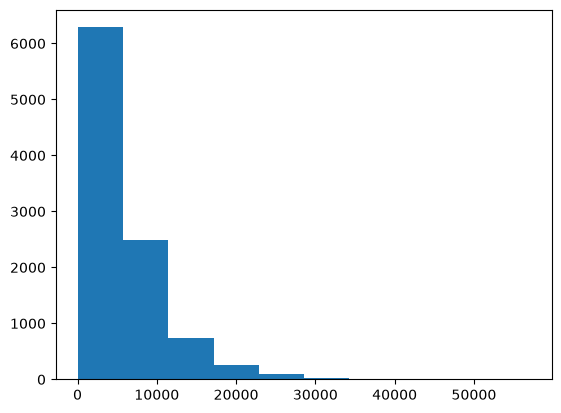

In [741]:
plt.hist(cleaned_dataset["cost"])
plt.show()

If all goes well, you made a histogram in the figure above. The histogram has a parameter called 'bins'. 

##### ❓Try setting bins to different values. Can you figure out what it does? Try to find a good value for bins for cost.

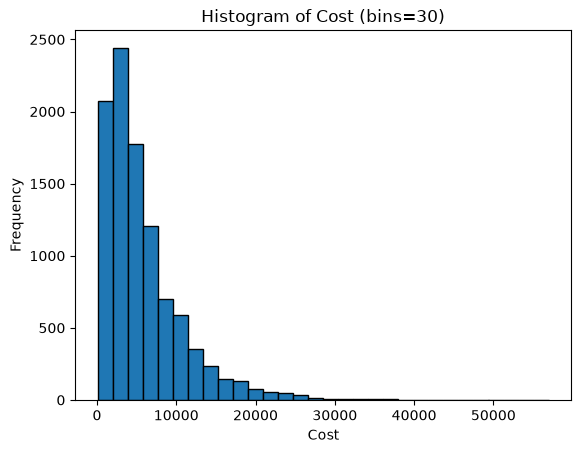

In [742]:
plt.hist(cleaned_dataset["cost"], bins=30, edgecolor="black")
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.title("Histogram of Cost (bins=30)")
plt.show()

##### ❓How would you interpret this histogram? Use the same questions as with the boxplot to formulate your answer

My interpretation:
- Symmetry / Skewness: The histogram clearly shows a unimodal, right-skewed distribution. The peak frequency is on the left (between 1,000 and 5,000), followed by a long tail trailing off toward higher values on the right.
- Spread: The distribution spans from around 100 up to nearly 57,000, with the vast majority of counts concentrated below 10,000.
- Concentration: Most trips fall into the lower budget tiers, while the long right-hand tail contains high-value luxury/extended packages.

##### ❓Now make both of these figures again for age and interpret the results. You can write one conclusion in which you discuss both plots at ones if you prefer. Make sure to describe WHAT you see and WHERE you see it on the plot. (This time, make your own code and markdown boxes again.)

For categorical data, categories can often serve as a basis for comparison in other plots, like boxplots. This means you can use a single category to differentiate data within such plots. You can also produce the same type of plot multiple times, once for each category, to analyze patterns within individual categories.


| Plot Type     | Description                                          | When to Use                                         |
|---------------|------------------------------------------------------|-----------------------------------------------------|
| **Count Plot**| Represents the frequency or count of each category.  | To see how often each category appears in the data. |

Count plots require an additional package, called seaborn. We will learn how to make plots with seaborn in the next lab.

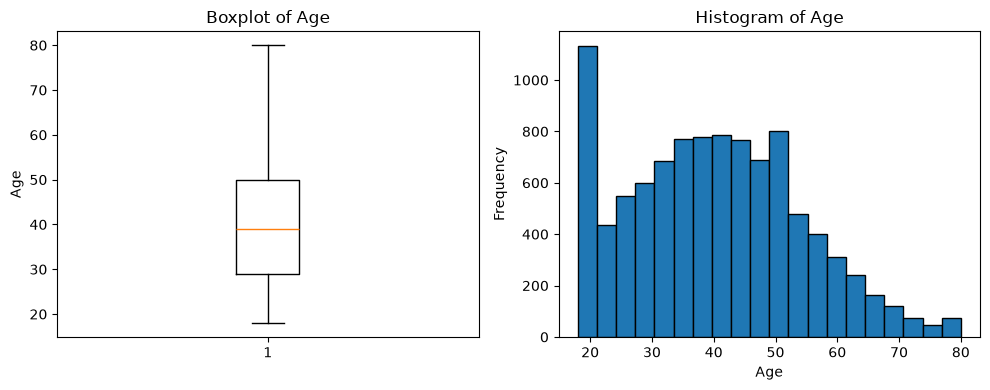

In [743]:
plt.figure(figsize=(10, 4))

# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot(cleaned_dataset["age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")

# Histogram
plt.subplot(1, 2, 2)
plt.hist(cleaned_dataset["age"], bins=20, edgecolor="black")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Conclusion for Age:
- Boxplot (left): The median line sits near the center of the box at 39, with $Q_1 = 29$ and $Q_3 = 50$. The whiskers extend evenly in both directions from 18 to 80, with zero outlier points outside the whiskers.
- Histogram (right): The distribution is symmetrical and roughly uniform, showing evenly leveled bars across all adult age groups between 18 and 80.
- Interpretation: Unlike cost, which is strongly right-skewed, traveler ages are evenly distributed across all brackets with no skewness or outliers.